## WATERMARK DETECTION AND SEGMENTATION USING GROUNDING DINO AND SAM

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.chouda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [3]:
%cd /content

!git clone https://github.com/IDEA-Research/Grounded-SAM-2.git

%cd /content/Grounded-SAM-2

/content
Cloning into 'Grounded-SAM-2'...
remote: Enumerating objects: 2065, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 2065 (delta 11), reused 5 (delta 5), pack-reused 2046 (from 2)
Receiving objects: 100% (2065/2065), 230.08 MiB | 19.39 MiB/s, done.
Resolving deltas: 100% (769/769), done.
/content/Grounded-SAM-2


In [4]:
!python -m pip install -U pip setuptools wheel

# Colab usually already has torch installed, but this makes sure torch/torchvision exist.
!pip install -q torch torchvision torchaudio

# Install SAM 2 package from this repo.
# SAM2_BUILD_CUDA=0 avoids CUDA extension build issues on Colab.
!SAM2_BUILD_CUDA=0 pip install -q -e ".[notebooks]"

# Extra packages used by the Grounded-SAM-2 image demo.
!pip install -q transformers accelerate supervision pycocotools opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.2 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 75.2.0
    Uninstalling setuptools-75.2.0:
      Successfully uninstalled setuptools-75.2.0
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
torch 2.11.0+cu128 requires setuptools<82, but you have setuptools 83.0.0 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires j

In [5]:
%cd /content/Grounded-SAM-2

!mkdir -p checkpoints

!wget -nc -P checkpoints \
https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

/content/Grounded-SAM-2
--2026-07-08 12:05:02--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.4, 65.9.168.62, 65.9.168.81, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 898083611 (856M) [application/vnd.snesdev-page-table]
Saving to: ‘checkpoints/sam2.1_hiera_large.pt’

sam2.1_hiera_large. 100%[===================>] 856.48M  34.4MB/s    in 11s     

2026-07-08 12:05:14 (77.2 MB/s) - ‘checkpoints/sam2.1_hiera_large.pt’ saved [898083611/898083611]



In [5]:
%cd /content/Grounded-SAM-2

!python grounded_sam2_hf_model_demo.py \
  --img-path "/content/微信图片_20260508222314_155_1.png" \
  --text-prompt "watermark. logo. text overlay. brand mark." \
  --output-dir "/content/grounded_sam2_outputs" \
  --sam2-checkpoint "./checkpoints/sam2.1_hiera_large.pt" \
  --sam2-model-config "configs/sam2.1/sam2.1_hiera_l.yaml"

/content/Grounded-SAM-2
preprocessor_config.json: 100% 457/457 [00:00<00:00, 2.22MB/s]
config.json: 100% 1.64k/1.64k [00:00<00:00, 5.16MB/s]
tokenizer_config.json: 100% 1.24k/1.24k [00:00<00:00, 5.26MB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 20.5MB/s]
tokenizer.json: 100% 711k/711k [00:00<00:00, 97.0MB/s]
added_tokens.json: 100% 82.0/82.0 [00:00<00:00, 439kB/s]
special_tokens_map.json: 100% 125/125 [00:00<00:00, 531kB/s]
model.safetensors: 100% 689M/689M [00:06<00:00, 109MB/s]
Loading weights: 100% 978/978 [00:00<00:00, 5868.88it/s]


In [6]:
# Extract SAM masks from Grounded-SAM-2 JSON and save PNG masks

import json
import re
from pathlib import Path

import numpy as np
from PIL import Image
import pycocotools.mask as mask_util


OUTPUT_DIR = Path("/content/grounded_sam2_outputs")
JSON_PATH = OUTPUT_DIR / "grounded_sam2_hf_model_demo_results.json"

MASK_OUTPUT_DIR = OUTPUT_DIR / "masks"
MASK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


with open(JSON_PATH, "r") as f:
    data = json.load(f)


height = data["img_height"]
width = data["img_width"]

combined_mask = np.zeros((height, width), dtype=np.uint8)


for idx, ann in enumerate(data["annotations"]):
    class_name = ann["class_name"]
    safe_class_name = re.sub(r"[^a-zA-Z0-9_-]+", "_", class_name)

    # Decode RLE mask to binary mask
    mask = mask_util.decode(ann["segmentation"])

    # Convert 0/1 mask to 0/255 mask
    mask_png = (mask.astype(np.uint8) * 255)

    # Save individual mask
    mask_path = MASK_OUTPUT_DIR / f"mask_{idx:03d}_{safe_class_name}.png"
    Image.fromarray(mask_png).save(mask_path)

    # Add to combined mask
    combined_mask = np.maximum(combined_mask, mask_png)

    print("saved:", mask_path)


combined_mask_path = MASK_OUTPUT_DIR / "combined_mask.png"
Image.fromarray(combined_mask).save(combined_mask_path)

print("combined mask:", combined_mask_path)

saved: /content/grounded_sam2_outputs/masks/mask_000_text_overlay.png
saved: /content/grounded_sam2_outputs/masks/mask_001_watermark.png
saved: /content/grounded_sam2_outputs/masks/mask_002_brand_mark.png
combined mask: /content/grounded_sam2_outputs/masks/combined_mask.png


## WATERMARK DETECTION AND SEGMENTATION

In [1]:
!apt-get update -qq
!apt-get install -y git-lfs
!git lfs install


!git clone https://huggingface.co/spaces/fancyfeast/joycaption-watermark-detection

!pip install ultralytics

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 130 not upgraded.
Need to get 3,544 kB of archives.
After this operation, 10.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 git-lfs amd64 3.0.2-1ubuntu0.3 [3,544 kB]
Fetched 3,544 kB in 0s (45.6 MB/s)
Selecting previously unselected package git-lfs.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...
Git LFS initialized.
Cloning in

In [22]:
# ============================================================
# YOLO watermark detector + SAM 2 mask generation
# ============================================================

from pathlib import Path
import json
import shutil

import cv2
import numpy as np
from PIL import Image

import torch
import torch.nn.functional as F
from torch import nn

import torchvision.transforms.functional as TVF
from transformers import Owlv2VisionModel
from ultralytics import YOLO

# SAM 2 imports
import sys
sys.path.append("/content/Grounded-SAM-2")

from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor


# -----------------------------
# Config
# -----------------------------

IMAGE_PATH = "/content/img2.png"   # change this

CLASSIFIER_WEIGHTS = "/content/far5y1y5-8000.pt"
YOLO_WEIGHTS = "/content/yolo11x-train28-best.pt"

SAM2_CHECKPOINT = "/content/Grounded-SAM-2/checkpoints/sam2.1_hiera_large.pt"
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"

OUTPUT_ROOT = Path("/content/yolo_sam2_outputs")

YOLO_CONF = 0.25
YOLO_IOU = 0.5
YOLO_IMGSZ = 1024

# If True, skip YOLO/SAM when classifier says no watermark.
SKIP_IF_CLASSIFIER_SAYS_NO_WATERMARK = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# OWLv2 classifier
# ============================================================

class DetectorModelOwl(nn.Module):
    def __init__(self, model_path: str, dropout: float = 0.0, n_hidden: int = 768):
        super().__init__()

        owl = Owlv2VisionModel.from_pretrained(model_path)
        assert isinstance(owl, Owlv2VisionModel)

        self.owl = owl
        self.owl.requires_grad_(False)

        self.dropout1 = nn.Dropout(dropout)
        self.ln1 = nn.LayerNorm(n_hidden, eps=1e-5)
        self.linear1 = nn.Linear(n_hidden, n_hidden * 2)
        self.act1 = nn.GELU()

        self.dropout2 = nn.Dropout(dropout)
        self.ln2 = nn.LayerNorm(n_hidden * 2, eps=1e-5)
        self.linear2 = nn.Linear(n_hidden * 2, 2)

    def forward(self, pixel_values: torch.Tensor, labels: torch.Tensor | None = None):
        outputs = self.owl(pixel_values=pixel_values, output_hidden_states=True)

        x = outputs.last_hidden_state

        x = self.dropout1(x)
        x = self.ln1(x)
        x = self.linear1(x)
        x = self.act1(x)

        x = self.dropout2(x)

        # Original repo uses max pooling over tokens.
        x, _ = x.max(dim=1)

        x = self.ln2(x)
        x = self.linear2(x)

        if labels is not None:
            loss = F.cross_entropy(x, labels)
            return x, loss

        return (x,)


def preprocess_for_owl(image: Image.Image) -> torch.Tensor:
    image = image.convert("RGB")

    big_side = max(image.size)
    padded = Image.new("RGB", (big_side, big_side), (128, 128, 128))
    padded.paste(image, (0, 0))

    resized = padded.resize((960, 960), Image.BICUBIC)

    tensor = TVF.pil_to_tensor(resized).float() / 255.0

    tensor = TVF.normalize(
        tensor,
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711],
    )

    return tensor.unsqueeze(0)


def load_classifier(weights_path: str = CLASSIFIER_WEIGHTS) -> DetectorModelOwl:
    model = DetectorModelOwl(
        model_path="google/owlv2-base-patch16-ensemble",
        dropout=0.0,
    )

    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()

    return model


@torch.no_grad()
def classify_watermark(image: Image.Image, model: DetectorModelOwl) -> dict:
    input_tensor = preprocess_for_owl(image).to(device)

    logits, = model(input_tensor)
    probs = F.softmax(logits, dim=1)[0]

    prob_not_watermarked = float(probs[0].detach().cpu())
    prob_watermarked = float(probs[1].detach().cpu())

    predicted_class = int(torch.argmax(probs).detach().cpu())
    label = "Watermarked" if predicted_class == 1 else "Not Watermarked"

    return {
        "label": label,
        "is_watermarked": predicted_class == 1,
        "prob_not_watermarked": prob_not_watermarked,
        "prob_watermarked": prob_watermarked,
    }


# ============================================================
# YOLO detector
# ============================================================

def load_yolo(weights_path: str = YOLO_WEIGHTS) -> YOLO:
    model = YOLO(weights_path)
    return model


def detect_watermarks_yolo(
    image: Image.Image,
    yolo_model: YOLO,
    conf: float = 0.25,
    iou: float = 0.5,
    imgsz: int = 1024,
) -> list[dict]:
    image = image.convert("RGB")

    results = yolo_model(
        image,
        imgsz=imgsz,
        conf=conf,
        iou=iou,
        augment=True,
        verbose=False,
    )

    result = results[0]

    boxes = []

    if result.boxes is not None:
        for box in result.boxes:
            xyxy = box.xyxy[0].detach().cpu().tolist()
            score = float(box.conf[0].detach().cpu())
            cls_id = int(box.cls[0].detach().cpu())

            class_name = yolo_model.names.get(cls_id, str(cls_id))

            boxes.append(
                {
                    "class_id": cls_id,
                    "class_name": class_name,
                    "confidence": score,
                    "xyxy": xyxy,
                }
            )

    return boxes


# ============================================================
# SAM 2
# ============================================================

def load_sam2_predictor(
    checkpoint_path: str = SAM2_CHECKPOINT,
    config_path: str = SAM2_CONFIG,
) -> SAM2ImagePredictor:
    sam2_model = build_sam2(
        config_file=config_path,
        ckpt_path=checkpoint_path,
        device=device,
    )

    predictor = SAM2ImagePredictor(sam2_model)
    return predictor


def run_sam2_on_yolo_boxes(
    image: Image.Image,
    boxes: list[dict],
    predictor: SAM2ImagePredictor,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Returns:
        masks: np.ndarray, shape [N, H, W], values 0/1
        sam_scores: np.ndarray, shape [N]
    """

    if len(boxes) == 0:
        width, height = image.size
        return np.zeros((0, height, width), dtype=np.uint8), np.array([])

    image_rgb = image.convert("RGB")
    image_np = np.array(image_rgb)

    predictor.set_image(image_np)

    input_boxes = np.array(
        [box["xyxy"] for box in boxes],
        dtype=np.float32,
    )

    masks, sam_scores, logits = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_boxes,
        multimask_output=False,
    )

    # Common SAM 2 shape for multiple boxes: [N, 1, H, W]
    if masks.ndim == 4:
        masks = masks.squeeze(1)

    masks = masks.astype(np.uint8)

    return masks, sam_scores


# ============================================================
# Save masks, annotated image, and JSON
# ============================================================

def create_combined_mask(masks: np.ndarray) -> np.ndarray:
    if masks.shape[0] == 0:
        return np.zeros(masks.shape[1:], dtype=np.uint8)

    combined = np.any(masks.astype(bool), axis=0).astype(np.uint8) * 255
    return combined


def draw_yolo_sam2_result(
    image: Image.Image,
    boxes: list[dict],
    masks: np.ndarray,
) -> Image.Image:
    image_np = np.array(image.convert("RGB"))
    annotated = image_np.copy()

    for idx, box in enumerate(boxes):
        x1, y1, x2, y2 = [int(v) for v in box["xyxy"]]
        label = box["class_name"]
        confidence = box["confidence"]

        if idx < len(masks):
            mask = masks[idx].astype(bool)

            overlay = annotated.copy()
            overlay[mask] = [0, 255, 0]
            annotated = cv2.addWeighted(overlay, 0.35, annotated, 0.65, 0)

        cv2.rectangle(
            annotated,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2,
        )

        cv2.putText(
            annotated,
            f"{label} {confidence:.2f}",
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

    return Image.fromarray(annotated)


def save_yolo_sam2_outputs(
    image_path: str,
    image: Image.Image,
    boxes: list[dict],
    masks: np.ndarray,
    sam_scores: np.ndarray,
    output_root: Path = OUTPUT_ROOT,
) -> dict:
    image_path = Path(image_path)
    image_stem = image_path.stem

    output_dir = output_root / image_stem
    masks_dir = output_dir / "masks"

    shutil.rmtree(output_dir, ignore_errors=True)
    masks_dir.mkdir(parents=True, exist_ok=True)

    combined_mask = create_combined_mask(masks)

    combined_mask_path = masks_dir / "combined_mask.png"
    Image.fromarray(combined_mask).save(combined_mask_path)

    individual_mask_paths = []

    for idx, mask in enumerate(masks):
        mask_png = mask.astype(np.uint8) * 255
        mask_path = masks_dir / f"mask_{idx:03d}.png"
        Image.fromarray(mask_png).save(mask_path)
        individual_mask_paths.append(str(mask_path))

    annotated_image = draw_yolo_sam2_result(
        image=image,
        boxes=boxes,
        masks=masks,
    )

    annotated_path = output_dir / "yolo_sam2_annotated_image_with_mask.jpg"
    annotated_image.save(annotated_path)

    results_json_path = output_dir / "yolo_sam2_results.json"

    payload = {
        "provider": "yolo_sam2",
        "image_path": str(image_path),
        "image_width": image.width,
        "image_height": image.height,
        "num_detections": len(boxes),
        "combined_mask_path": str(combined_mask_path),
        "annotated_image_path": str(annotated_path),
        "detections": [],
    }

    for idx, box in enumerate(boxes):
        payload["detections"].append(
            {
                "class_id": box["class_id"],
                "class_name": box["class_name"],
                "confidence": box["confidence"],
                "xyxy": box["xyxy"],
                "sam_score": float(sam_scores[idx]) if idx < len(sam_scores) else None,
                "mask_path": individual_mask_paths[idx] if idx < len(individual_mask_paths) else None,
            }
        )

    with open(results_json_path, "w") as f:
        json.dump(payload, f, indent=2)

    return {
        "output_dir": str(output_dir),
        "combined_mask_path": str(combined_mask_path),
        "annotated_image_path": str(annotated_path),
        "results_json_path": str(results_json_path),
    }


# ============================================================
# Full pipeline: classifier -> YOLO -> SAM 2
# ============================================================

def run_yolo_sam2_watermark_pipeline(
    image_path: str,
    classifier_weights: str = CLASSIFIER_WEIGHTS,
    yolo_weights: str = YOLO_WEIGHTS,
    skip_if_classifier_says_no_watermark: bool = False,
) -> dict:
    image = Image.open(image_path).convert("RGB")

    print("Loading classifier...")
    classifier_model = load_classifier(classifier_weights)

    print("Running classifier...")
    classifier_result = classify_watermark(image, classifier_model)

    print("Classifier result:")
    print(classifier_result)

    if skip_if_classifier_says_no_watermark and not classifier_result["is_watermarked"]:
        print("Classifier says image is not watermarked. Skipping YOLO/SAM.")

        image_stem = Path(image_path).stem
        output_dir = OUTPUT_ROOT / image_stem
        masks_dir = output_dir / "masks"

        shutil.rmtree(output_dir, ignore_errors=True)
        masks_dir.mkdir(parents=True, exist_ok=True)

        empty_mask = np.zeros((image.height, image.width), dtype=np.uint8)
        combined_mask_path = masks_dir / "combined_mask.png"
        Image.fromarray(empty_mask).save(combined_mask_path)

        return {
            "classifier_result": classifier_result,
            "yolo_boxes": [],
            "combined_mask_path": str(combined_mask_path),
            "output_dir": str(output_dir),
        }

    print("Loading YOLO...")
    yolo_model = load_yolo(yolo_weights)

    print("Running YOLO...")
    yolo_boxes = detect_watermarks_yolo(
        image=image,
        yolo_model=yolo_model,
        conf=YOLO_CONF,
        iou=YOLO_IOU,
        imgsz=YOLO_IMGSZ,
    )

    print(f"YOLO detections: {len(yolo_boxes)}")
    for box in yolo_boxes:
        print(box)

    print("Loading SAM 2...")
    sam2_predictor = load_sam2_predictor()

    print("Running SAM 2 on YOLO boxes...")
    masks, sam_scores = run_sam2_on_yolo_boxes(
        image=image,
        boxes=yolo_boxes,
        predictor=sam2_predictor,
    )

    print("Saving outputs...")
    saved = save_yolo_sam2_outputs(
        image_path=image_path,
        image=image,
        boxes=yolo_boxes,
        masks=masks,
        sam_scores=sam_scores,
    )

    return {
        "classifier_result": classifier_result,
        "yolo_boxes": yolo_boxes,
        "sam_scores": sam_scores.tolist() if hasattr(sam_scores, "tolist") else [],
        **saved,
    }


# ============================================================
# Run
# ============================================================

result = run_yolo_sam2_watermark_pipeline(
    image_path=IMAGE_PATH,
    classifier_weights=CLASSIFIER_WEIGHTS,
    yolo_weights=YOLO_WEIGHTS,
    skip_if_classifier_says_no_watermark=SKIP_IF_CLASSIFIER_SAYS_NO_WATERMARK,
)

print("\nFinal result:")
print(result)

Using device: cuda
Loading classifier...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] Owlv2VisionModel LOAD REPORT from: google/owlv2-base-patch16-ensemble
Key                                                                | Status     |  | 
-------------------------------------------------------------------+------------+--+-
owlv2.text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
owlv2.text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
owlv2.text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
owlv2.text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
owlv2.text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
owlv2.text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
objectness_head.dense0.bias                                        | UNEXPECTED |  | 
owlv2.text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
owlv2.text_model.encoder.layers.{0...11}.layer_norm2.bi

Running classifier...
Classifier result:
{'label': 'Not Watermarked', 'is_watermarked': False, 'prob_not_watermarked': 0.7760868072509766, 'prob_watermarked': 0.22391320765018463}
Loading YOLO...
Running YOLO...
YOLO detections: 1
{'class_id': 0, 'class_name': 'watermark', 'confidence': 0.7404512166976929, 'xyxy': [376.122802734375, 572.048095703125, 825.4337158203125, 627.4174194335938]}
Loading SAM 2...
Running SAM 2 on YOLO boxes...
Saving outputs...

Final result:
{'classifier_result': {'label': 'Not Watermarked', 'is_watermarked': False, 'prob_not_watermarked': 0.7760868072509766, 'prob_watermarked': 0.22391320765018463}, 'yolo_boxes': [{'class_id': 0, 'class_name': 'watermark', 'confidence': 0.7404512166976929, 'xyxy': [376.122802734375, 572.048095703125, 825.4337158203125, 627.4174194335938]}], 'sam_scores': [0.6197383403778076], 'output_dir': '/content/yolo_sam2_outputs/img2', 'combined_mask_path': '/content/yolo_sam2_outputs/img2/masks/combined_mask.png', 'annotated_image_path

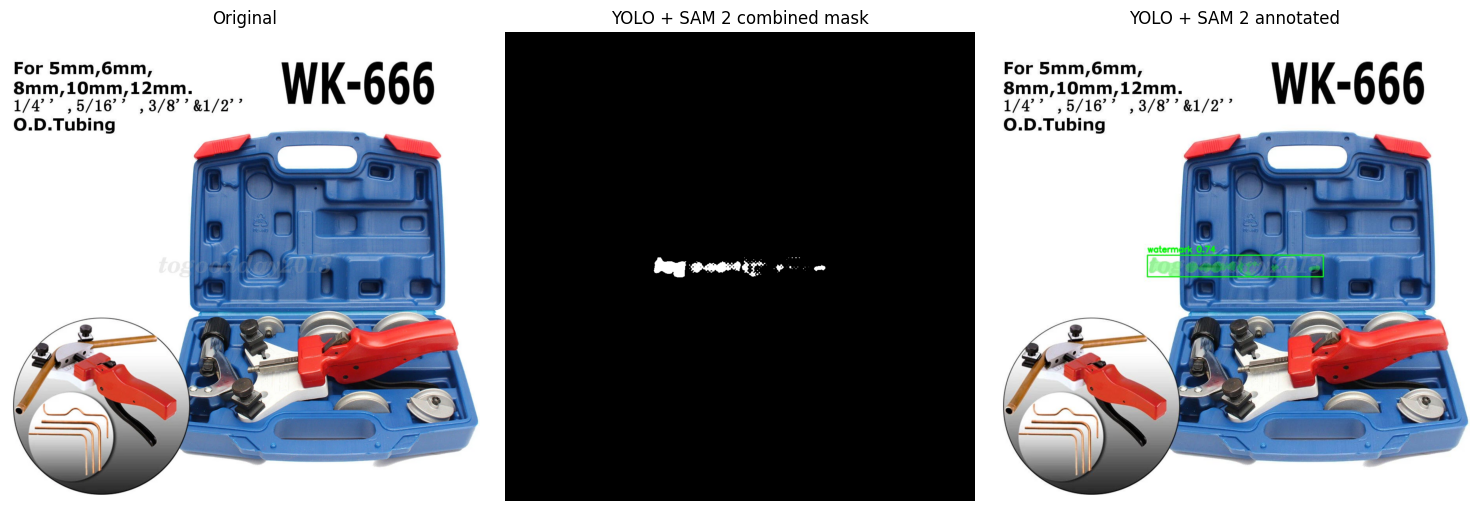

Combined mask path: /content/yolo_sam2_outputs/img2/masks/combined_mask.png
Annotated path: /content/yolo_sam2_outputs/img2/yolo_sam2_annotated_image_with_mask.jpg


In [23]:
from PIL import Image
import matplotlib.pyplot as plt

annotated_path = result["annotated_image_path"]
combined_mask_path = result["combined_mask_path"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(Image.open(IMAGE_PATH).convert("RGB"))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(Image.open(combined_mask_path).convert("L"), cmap="gray")
axes[1].set_title("YOLO + SAM 2 combined mask")
axes[1].axis("off")

axes[2].imshow(Image.open(annotated_path).convert("RGB"))
axes[2].set_title("YOLO + SAM 2 annotated")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Combined mask path:", combined_mask_path)
print("Annotated path:", annotated_path)

## IMAGE INPAINTING USING LAMA

In [24]:
# @title 1. Install LaMa and download big-lama model

import os
import shutil
import subprocess
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()

WORKDIR = Path("/content/lama_workspace")
LAMA_DIR = WORKDIR / "lama"
MODEL_DIR = WORKDIR / "big-lama"
MODEL_ZIP = WORKDIR / "big-lama.zip"
MODEL_URL = "https://huggingface.co/smartywu/big-lama/resolve/main/big-lama.zip"

INPUT_ROOT = WORKDIR / "inputs"
OUTPUT_ROOT = WORKDIR / "outputs"

WORKDIR.mkdir(parents=True, exist_ok=True)
INPUT_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


def run(cmd, cwd=None, env=None):
    cmd = [str(part) for part in cmd]
    print("$", " ".join(cmd))

    completed = subprocess.run(
        cmd,
        cwd=cwd,
        env=env,
        text=True,
        capture_output=True,
    )

    if completed.stdout:
        print(completed.stdout)

    if completed.stderr:
        print(completed.stderr, file=sys.stderr)

    if completed.returncode != 0:
        raise subprocess.CalledProcessError(
            completed.returncode,
            cmd,
            output=completed.stdout,
            stderr=completed.stderr,
        )

    return completed


# Basic dependencies
try:
    import torch
    print(f"torch {torch.__version__}; cuda available: {torch.cuda.is_available()}")
except Exception:
    run([sys.executable, "-m", "pip", "install", "-q", "torch", "torchvision"])


PIP_PACKAGES = [
    "albumentations==1.3.1",
    "imgaug==0.4.0",
    "hydra-core==1.3.2",
    "omegaconf==2.3.0",
    "pytorch-lightning==1.9.5",
    "torchmetrics==0.11.4",
    "kornia==0.7.4",
    "torchvision",
    "webdataset",
    "opencv-python-headless",
    "scikit-image",
    "scikit-learn",
    "pandas",
    "matplotlib",
    "tqdm",
    "PyYAML",
    "easydict",
]

run([sys.executable, "-m", "pip", "install", "-q", *PIP_PACKAGES])


# Clone LaMa
if not (LAMA_DIR / ".git").exists():
    run(["git", "clone", "--depth", "1", "https://github.com/advimman/lama.git", LAMA_DIR])
else:
    run(["git", "-C", LAMA_DIR, "reset", "--hard", "HEAD"])
    run(["git", "-C", LAMA_DIR, "pull", "--ff-only"])


def patch_file(path, replacements):
    path = Path(path)
    text = path.read_text()
    original = text

    for old, new in replacements:
        if old in text and new not in text:
            text = text.replace(old, new)

    if text != original:
        path.write_text(text)
        print(f"patched {path.relative_to(LAMA_DIR)}")


# Patch NumPy compatibility for newer Colab environments
sitecustomize = LAMA_DIR / "sitecustomize.py"
sitecustomize.write_text(
    "import numpy as _np\n"
    "if not hasattr(_np, 'sctypes'):\n"
    "    _np.sctypes = {\n"
    "        'int': [_np.int8, _np.int16, _np.int32, _np.int64],\n"
    "        'uint': [_np.uint8, _np.uint16, _np.uint32, _np.uint64],\n"
    "        'float': [_np.float16, _np.float32, _np.float64],\n"
    "        'complex': [_np.complex64, _np.complex128],\n"
    "        'others': [bool, object, bytes, str],\n"
    "    }\n"
    "for _name, _value in {'bool': _np.bool_, 'int': int, 'float': float, 'complex': complex, 'object': object}.items():\n"
    "    if not hasattr(_np, _name):\n"
    "        setattr(_np, _name, _value)\n"
)


# Patch LaMa to use GPU if available
patch_file(
    LAMA_DIR / "bin" / "predict.py",
    [
        (
            'device = torch.device("cpu")',
            'device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n        LOGGER.info(f"Using device: {device}")',
        )
    ],
)


# Patch torch.load compatibility
patch_file(
    LAMA_DIR / "saicinpainting" / "training" / "trainers" / "__init__.py",
    [
        (
            "import torch\n",
            "import torch\n\n\ndef _torch_load_compat(path, map_location):\n"
            "    try:\n"
            "        return torch.load(path, map_location=map_location, weights_only=False)\n"
            "    except TypeError:\n"
            "        return torch.load(path, map_location=map_location)\n",
        ),
        (
            "state = torch.load(path, map_location=map_location)",
            "state = _torch_load_compat(path, map_location)",
        ),
    ],
)


# Download big-lama model
if not MODEL_ZIP.exists():
    run(["wget", "-q", "--show-progress", "-O", MODEL_ZIP, MODEL_URL])

if not (MODEL_DIR / "config.yaml").exists():
    shutil.rmtree(MODEL_DIR, ignore_errors=True)
    run(["unzip", "-q", "-o", MODEL_ZIP, "-d", WORKDIR])

if not (MODEL_DIR / "config.yaml").exists():
    raise FileNotFoundError(f"Expected model config at {MODEL_DIR / 'config.yaml'}")


os.environ["PYTHONPATH"] = str(LAMA_DIR) + os.pathsep + os.environ.get("PYTHONPATH", "")

print("LaMa setup ready.")
print("workspace:", WORKDIR)
print("repo:", LAMA_DIR)
print("model:", MODEL_DIR)

torch 2.11.0+cu128; cuda available: True
$ /usr/bin/python3 -m pip install -q albumentations==1.3.1 imgaug==0.4.0 hydra-core==1.3.2 omegaconf==2.3.0 pytorch-lightning==1.9.5 torchmetrics==0.11.4 kornia==0.7.4 torchvision webdataset opencv-python-headless scikit-image scikit-learn pandas matplotlib tqdm PyYAML easydict


/content/lama_workspace/lama/sitecustomize.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(_np, _name):



$ git -C /content/lama_workspace/lama reset --hard HEAD
HEAD is now at 786f593 Update README.md

$ git -C /content/lama_workspace/lama pull --ff-only
Already up to date.

patched bin/predict.py
patched saicinpainting/training/trainers/__init__.py
LaMa setup ready.
workspace: /content/lama_workspace
repo: /content/lama_workspace/lama
model: /content/lama_workspace/big-lama


In [25]:
# @title 2. Define LaMa helper functions

import os
import shutil
import sys
from pathlib import Path

import numpy as np
from PIL import Image, ImageFilter


def run_lama_folder(input_dir, output_dir):
    input_dir = Path(input_dir).resolve()
    output_dir = Path(output_dir).resolve()
    output_dir.mkdir(parents=True, exist_ok=True)

    env = os.environ.copy()
    env["PYTHONPATH"] = str(LAMA_DIR) + os.pathsep + env.get("PYTHONPATH", "")

    run(
        [
            sys.executable,
            LAMA_DIR / "bin" / "predict.py",
            f"model.path={MODEL_DIR}",
            f"indir={input_dir}",
            f"outdir={output_dir}",
            "+out_ext=.png",
        ],
        cwd=LAMA_DIR,
        env=env,
    )

    return output_dir


def prepare_lama_mask(mask_path, target_size, dilate_px=0, threshold=127):
    """
    Converts SAM/Grounded-SAM-2 mask into LaMa-compatible binary mask.

    LaMa expects:
    - white/255 = area to inpaint/remove
    - black/0 = area to keep
    """

    mask = Image.open(mask_path).convert("L")

    if mask.size != target_size:
        mask = mask.resize(target_size, Image.NEAREST)

    mask_np = np.array(mask)
    binary_np = np.where(mask_np > threshold, 255, 0).astype(np.uint8)
    binary_mask = Image.fromarray(binary_np, mode="L")

    if dilate_px > 0:
        # MaxFilter size must be odd.
        kernel_size = dilate_px * 2 + 1
        binary_mask = binary_mask.filter(ImageFilter.MaxFilter(kernel_size))

    return binary_mask


def run_lama_on_pair(
    image_path,
    mask_path,
    job_name="lama_job",
    dilate_px=2,
    threshold=127,
):
    """
    Runs LaMa on one original image + one segmentation mask.

    image_path:
        Original image path.

    mask_path:
        SAM/Grounded-SAM-2 mask path.
        White/positive region should represent the watermark/object to remove.

    dilate_px:
        Slightly expands the mask.
        For watermark removal, 1-4 px is usually helpful.
    """

    image_path = Path(image_path)
    mask_path = Path(mask_path)

    if not image_path.exists():
        raise FileNotFoundError(f"Image not found: {image_path}")

    if not mask_path.exists():
        raise FileNotFoundError(f"Mask not found: {mask_path}")

    image = Image.open(image_path).convert("RGB")
    mask = prepare_lama_mask(
        mask_path=mask_path,
        target_size=image.size,
        dilate_px=dilate_px,
        threshold=threshold,
    )

    job_dir = INPUT_ROOT / job_name
    out_dir = OUTPUT_ROOT / job_name

    shutil.rmtree(job_dir, ignore_errors=True)
    shutil.rmtree(out_dir, ignore_errors=True)

    job_dir.mkdir(parents=True, exist_ok=True)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Important:
    # LaMa needs image + mask in the same folder.
    # Mask should be named image_name_mask.png.
    image_target = job_dir / f"{job_name}.png"
    mask_target = job_dir / f"{job_name}_mask.png"

    image.save(image_target)
    mask.save(mask_target)

    run_lama_folder(job_dir, out_dir)

    possible_outputs = [
        out_dir / f"{job_name}.png",
        out_dir / f"{job_name}_mask.png",
    ]

    for output_path in possible_outputs:
        if output_path.exists():
            return output_path

    png_outputs = sorted(out_dir.glob("*.png"))

    if len(png_outputs) == 1:
        return png_outputs[0]

    raise FileNotFoundError(
        f"Could not find LaMa output in {out_dir}. "
        f"Found files: {[p.name for p in out_dir.iterdir()]}"
    )

In [26]:
# # @title 3. Run LaMa on your Grounded-SAM-2 mask

# ORIGINAL_IMAGE_PATH = "/content/微信图片_20260508222314_155_1.png"
# SAM_MASK_PATH = "/content/grounded_sam2_outputs/masks/combined_mask.png"

# result_path = run_lama_on_pair(
#     image_path=ORIGINAL_IMAGE_PATH,
#     mask_path=SAM_MASK_PATH,
#     job_name="watermark_test_lama",
#     dilate_px=2,
#     threshold=127,
# )

# print("LaMa result:", result_path)

# print("LaMa result:", result_path)


##### RUN THIS BLOCK IF YOU ARE USING THE YOLO + SAM PATH, OTHERWISE USE ABOVE CODE IF USING GROUNDINGDINO + SAM PATH
ORIGINAL_IMAGE_PATH = IMAGE_PATH
SAM_MASK_PATH = result["combined_mask_path"]

lama_result_path = run_lama_on_pair(
    image_path=ORIGINAL_IMAGE_PATH,
    mask_path=SAM_MASK_PATH,
    job_name=f"{Path(IMAGE_PATH).stem}_yolo_sam2_lama",
    dilate_px=2,
    threshold=127,
)

print("LaMa result:", lama_result_path)

/tmp/ipykernel_368/3222952280.py:52: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  binary_mask = Image.fromarray(binary_np, mode="L")


$ /usr/bin/python3 /content/lama_workspace/lama/bin/predict.py model.path=/content/lama_workspace/big-lama indir=/content/lama_workspace/inputs/img2_yolo_sam2_lama outdir=/content/lama_workspace/outputs/img2_yolo_sam2_lama +out_ext=.png
Detectron v2 is not installed
[2026-07-08 12:16:05,079][saicinpainting.utils][WARNING] - Setting signal 10 handler <function print_traceback_handler at 0x7c49be07d3a0>
[2026-07-08 12:16:05,112][__main__][INFO] - Using device: cuda
[2026-07-08 12:16:05,177][root][INFO] - Make training model default
[2026-07-08 12:16:05,179][saicinpainting.training.trainers.base][INFO] - BaseInpaintingTrainingModule init called
[2026-07-08 12:16:05,180][root][INFO] - Make generator ffc_resnet
[2026-07-08 12:16:06,911][saicinpainting.training.trainers.base][INFO] - Generator
FFCResNetGenerator(
  (model): Sequential(
    (0): ReflectionPad2d((3, 3, 3, 3))
    (1): FFC_BN_ACT(
      (ffc): FFC(
        (convl2l): Conv2d(4, 64, kernel_size=(7, 7), stride=(1, 1), bias=False, 

/content/lama_workspace/lama/sitecustomize.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(_np, _name):
/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/content/lama_workspace/lama/bin/predict.py:38: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path='../configs/prediction', config_name='default.yaml')
/usr/local/lib/python3.12/dist-packages/hydra/_internal/hydra.py:119: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See h

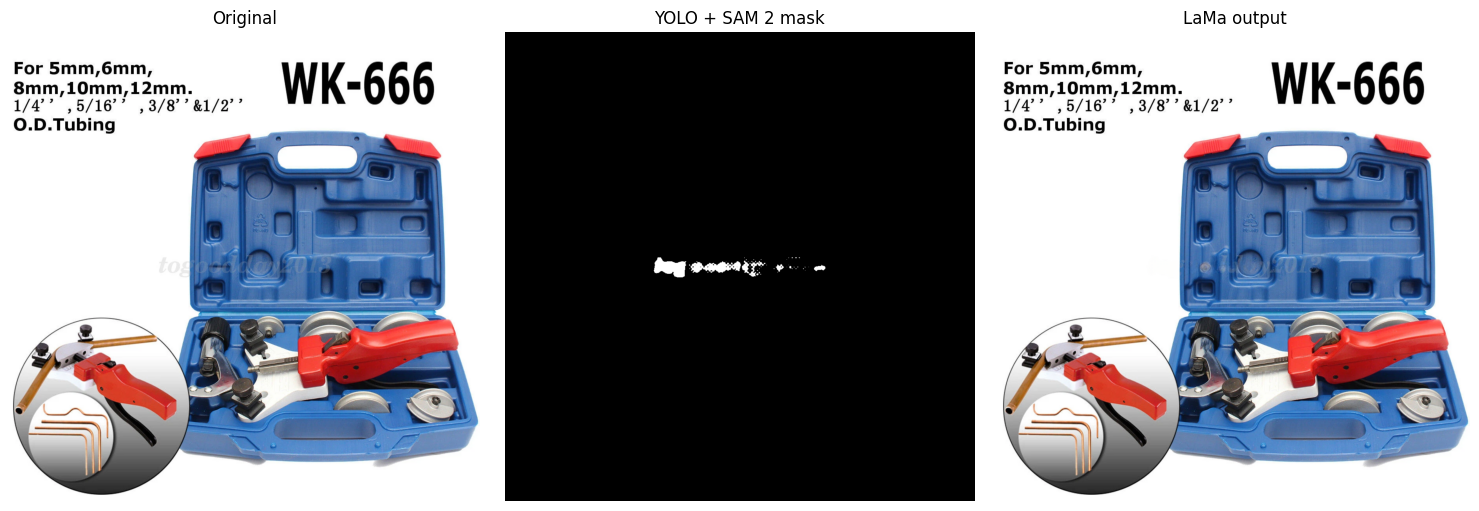

In [27]:
# # @title 4. View result

# import matplotlib.pyplot as plt
# from PIL import Image

# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# axes[0].imshow(Image.open(ORIGINAL_IMAGE_PATH).convert("RGB"))
# axes[0].set_title("Original image")
# axes[0].axis("off")

# axes[1].imshow(Image.open(SAM_MASK_PATH).convert("L"), cmap="gray")
# axes[1].set_title("SAM/Grounded-SAM-2 mask")
# axes[1].axis("off")

# axes[2].imshow(Image.open(result_path).convert("RGB"))
# axes[2].set_title("LaMa output")
# axes[2].axis("off")

# plt.tight_layout()
# plt.show()


##### RUN THIS BLOCK IF YOU ARE USING THE YOLO + SAM PATH, OTHERWISE USE ABOVE CODE IF USING GROUNDINGDINO + SAM PATH
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(Image.open(ORIGINAL_IMAGE_PATH).convert("RGB"))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(Image.open(SAM_MASK_PATH).convert("L"), cmap="gray")
axes[1].set_title("YOLO + SAM 2 mask")
axes[1].axis("off")

axes[2].imshow(Image.open(lama_result_path).convert("RGB"))
axes[2].set_title("LaMa output")
axes[2].axis("off")

plt.tight_layout()
plt.show()